# Semantic Drift via all-MiniLM-L6-v2 — Per-CIK Streaming Pipeline

Processes each `{cik}_filings.parquet` individually — no merge step needed.

| Stage | Description |
|---|---|
| 1 | Chunk `item_1` into 400-token windows (50-token overlap) |
| 2 | Embed each chunk with `all-MiniLM-L6-v2` (384-dim) |
| 3 | Mean-pool chunks → firm-year embedding |
| 4 | Compute YoY cosine drift: `SemanticDrift = 1 − cos(v_t, v_{t-1})` |

**Fully interruptible**: checkpoints per CIK to Google Drive. Stop any time, rerun to resume.

## 0. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

Mounted at /content/drive


## 1. Configuration

In [2]:
import os

CONFIG = {
    # Folder with {cik}/{cik}_filings.parquet subfolders (extractor output)
    'filings_folder': '/content/drive/MyDrive/FML_project_4',

    # Checkpoint + output folder (on Drive — survives runtime resets)
    'output_folder': '/content/drive/MyDrive/FML_project_4',

    # Section to use for strategic drift
    'section': 'item_1',

    # Model
    'model_name': 'sentence-transformers/all-MiniLM-L6-v2',

    # Chunking
    'chunk_size':    400,
    'chunk_overlap':  50,

    # Inference
    'embed_batch': 64,

    # Year range
    'start_year': 2004,
    'end_year':   2025,
}
print('Config OK')

Config OK


## 2. Install dependencies

In [3]:
import subprocess
subprocess.run(['pip', 'install', '-q',
    'sentence-transformers', 'transformers', 'torch', 'pyarrow', 'tqdm'], check=True)

import glob
import numpy as np
import pandas as pd
import torch
import gc
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from sklearn.metrics.pairwise import cosine_similarity

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cpu':
    print('WARNING: No GPU — embedding will be very slow.')

Device: cuda


## 3. Load model + tokenizer

In [4]:
model     = SentenceTransformer(CONFIG['model_name'], device=DEVICE)
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print(f'Model: {CONFIG["model_name"]}  |  dim: {model.get_sentence_embedding_dimension()}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model: sentence-transformers/all-MiniLM-L6-v2  |  dim: 384


/tmp/ipykernel_1008/2693778041.py:3: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f'Model: {CONFIG["model_name"]}  |  dim: {model.get_sentence_embedding_dimension()}')


## 4. Chunking helper

Splits each section into fixed 400-token windows with 50-token overlap,
using the model's own tokenizer for accurate token counting.

In [5]:
CHUNK_SIZE = CONFIG['chunk_size']
STRIDE     = CONFIG['chunk_overlap']


def chunk_text(text: str) -> list[str]:
    """Split text into fixed-size token windows. Returns decoded chunk strings."""
    if not text or len(text.split()) < 10:
        return []
    enc = tokenizer(
        text,
        max_length=CHUNK_SIZE,
        stride=STRIDE,
        return_overflowing_tokens=True,
        truncation=True,
        padding=False,
        add_special_tokens=False,
    )
    return [
        tokenizer.decode(ids, skip_special_tokens=True)
        for ids in enc['input_ids']
        if len(ids) > 10
    ]


# Smoke test
_test = chunk_text('The quick brown fox jumps over the lazy dog. ' * 200)
print(f'Smoke test: {len(_test)} chunks from ~1800 words')

Smoke test: 6 chunks from ~1800 words


## 5. Embedding helper

Mean-pool all chunk embeddings into a single firm-year vector:

$$V_t = \frac{1}{K} \sum_{k=1}^{K} \text{embedding}(\text{chunk}_k)$$

In [6]:
def embed_chunks(chunks: list[str]) -> np.ndarray | None:
    """Embed chunks → mean-pool → single 384-dim vector. None if no chunks."""
    if not chunks:
        return None
    embs = model.encode(
        chunks,
        batch_size=CONFIG['embed_batch'],
        show_progress_bar=False,
        convert_to_numpy=True,
    )
    return embs.mean(axis=0)

## 6. Discover CIK files + resume logic

Checkpoints are saved **per CIK to Google Drive** (`_minilm_checkpoints/{cik}.parquet`).
On rerun, already-processed CIKs are skipped automatically.

In [7]:
pq_files = sorted(glob.glob(
    os.path.join(CONFIG['filings_folder'], '**', '*_filings.parquet'), recursive=True
))
print(f'CIK parquet files found: {len(pq_files)}')

# Checkpoint dir ON DRIVE — one tiny parquet per CIK
CHECKPOINT_DIR = os.path.join(CONFIG['output_folder'], '_minilm_checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

done_ciks: set[str] = {
    os.path.basename(f).replace('.parquet', '')
    for f in glob.glob(f'{CHECKPOINT_DIR}/*.parquet')
}
print(f'Already processed: {len(done_ciks)} CIKs')
print(f'Remaining: ~{len(pq_files) - len(done_ciks)}')

CIK parquet files found: 977
Already processed: 0 CIKs
Remaining: ~977


## 7. Main loop — embed one CIK at a time

Each CIK is saved to Drive immediately after processing.
**Stop any time** (interrupt kernel, disconnect, close laptop) — no progress is lost.
Rerun this cell to continue.

In [8]:
section_col = CONFIG['section']
processed   = 0
skipped     = 0
failed      = 0

for pq_path in tqdm(pq_files, desc='CIKs'):

    cik = os.path.basename(pq_path).replace('_filings.parquet', '').lstrip('0')
    if not cik or cik in done_ciks:
        skipped += 1
        continue

    # ── Load ────────────────────────────────────────────────────────────
    try:
        df = pd.read_parquet(pq_path, columns=['cik', 'year', 'filing_date', section_col])
    except Exception:
        failed += 1
        continue

    df['cik']  = df['cik'].astype(str).str.strip().str.lstrip('0')
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
    df = df[df['year'].between(CONFIG['start_year'], CONFIG['end_year'])]
    df = (df.sort_values('filing_date', na_position='first')
            .drop_duplicates(subset=['cik', 'year'], keep='last')
            .sort_values('year')
            .reset_index(drop=True))

    if len(df) < 2:
        skipped += 1
        continue

    # ── Chunk + Embed each year ─────────────────────────────────────────
    rows: list[dict] = []
    for _, row in df.iterrows():
        text   = str(row.get(section_col, '') or '')
        chunks = chunk_text(text)
        emb    = embed_chunks(chunks)
        rows.append({
            'cik':      cik,
            'year':     int(row['year']),
            'emb':      emb.tolist() if emb is not None else None,
            'n_chunks': len(chunks),
        })

    # ── Save this CIK to Drive immediately ──────────────────────────────
    pd.DataFrame(rows).to_parquet(
        f'{CHECKPOINT_DIR}/{cik}.parquet', index=False, compression='snappy'
    )
    processed += 1

    if processed % 25 == 0:
        print(f'  ... {processed} CIKs done')
        gc.collect()

print(f'\nEmbedding done.  Processed: {processed}  Skipped: {skipped}  Failed: {failed}')
print(f'Total checkpoints on Drive: {len(glob.glob(f"{CHECKPOINT_DIR}/*.parquet"))}')

CIKs:   0%|          | 0/977 [00:00<?, ?it/s]

  ... 25 CIKs done
  ... 50 CIKs done
  ... 75 CIKs done
  ... 100 CIKs done
  ... 125 CIKs done
  ... 150 CIKs done
  ... 175 CIKs done
  ... 200 CIKs done
  ... 225 CIKs done
  ... 250 CIKs done
  ... 275 CIKs done
  ... 300 CIKs done
  ... 325 CIKs done
  ... 350 CIKs done
  ... 375 CIKs done
  ... 400 CIKs done
  ... 425 CIKs done
  ... 450 CIKs done
  ... 475 CIKs done
  ... 500 CIKs done
  ... 525 CIKs done
  ... 550 CIKs done
  ... 575 CIKs done
  ... 600 CIKs done
  ... 625 CIKs done
  ... 650 CIKs done
  ... 675 CIKs done
  ... 700 CIKs done
  ... 725 CIKs done
  ... 750 CIKs done
  ... 775 CIKs done
  ... 800 CIKs done
  ... 825 CIKs done
  ... 850 CIKs done
  ... 875 CIKs done
  ... 900 CIKs done
  ... 925 CIKs done
  ... 950 CIKs done

Embedding done.  Processed: 962  Skipped: 15  Failed: 0
Total checkpoints on Drive: 962


## 8. Compute semantic drift from checkpoints

Reads all per-CIK checkpoint files and computes:

$$\text{SemanticDrift}_{i,t} = 1 - \frac{v_{i,t} \cdot v_{i,t-1}}{\|v_{i,t}\| \cdot \|v_{i,t-1}\|}$$

**This cell is independent** — run it even if the embedding loop was interrupted to get partial results.

In [12]:
DRIFT_PATH = os.path.join(CONFIG['output_folder'], 'semantic_drift_minilm.parquet')
CHECKPOINT_DIR = os.path.join(CONFIG['output_folder'], '_minilm_checkpoints')

checkpoint_files = sorted(glob.glob(f'{CHECKPOINT_DIR}/*.parquet'))
print(f'Checkpoint files: {len(checkpoint_files)}')

drift_rows: list[dict] = []

for cf in tqdm(checkpoint_files, desc='Computing drift'):
    try:
        cik_df = pd.read_parquet(cf).sort_values('year').reset_index(drop=True)
    except Exception:
        continue

    if len(cik_df) < 2:
        continue

    cik = cik_df['cik'].iloc[0]

    for i in range(1, len(cik_df)):
        emb_curr = cik_df.loc[i, 'emb']
        emb_prev = cik_df.loc[i - 1, 'emb']

        if emb_curr is None or emb_prev is None:
            drift_rows.append({
                'cik':            cik,
                'year':           int(cik_df.loc[i, 'year']),
                'year_prev':      int(cik_df.loc[i - 1, 'year']),
                'semantic_drift': np.nan,
                'cosine_sim':     np.nan,
                'n_chunks_curr':  int(cik_df.loc[i, 'n_chunks']),
                'n_chunks_prev':  int(cik_df.loc[i - 1, 'n_chunks']),
            })
            continue

        v_curr = np.array(emb_curr, dtype=np.float32).reshape(1, -1)
        v_prev = np.array(emb_prev, dtype=np.float32).reshape(1, -1)
        sim    = float(cosine_similarity(v_curr, v_prev)[0, 0])

        drift_rows.append({
            'cik':            cik,
            'year':           int(cik_df.loc[i, 'year']),
            'year_prev':      int(cik_df.loc[i - 1, 'year']),
            'semantic_drift': round(1.0 - sim, 6),
            'cosine_sim':     round(sim, 6),
            'n_chunks_curr':  int(cik_df.loc[i, 'n_chunks']),
            'n_chunks_prev':  int(cik_df.loc[i - 1, 'n_chunks']),
        })

drift_df = pd.DataFrame(drift_rows)
drift_df['year'] = drift_df['year'].astype('Int64')
drift_df.to_parquet(DRIFT_PATH, index=False, compression='snappy')
print(f'Saved: {DRIFT_PATH}  ({len(drift_df):,} rows, {drift_df["cik"].nunique()} CIKs)')

Checkpoint files: 962


Computing drift:   0%|          | 0/962 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/FML_project_4/semantic_drift_minilm.parquet  (14,580 rows, 962 CIKs)


## 9. Summary statistics

In [13]:
valid = drift_df.dropna(subset=['semantic_drift'])

print(f'SEMANTIC DRIFT — all-MiniLM-L6-v2 on {CONFIG["section"]}')
print(f'{"=" * 50}')
print(f'Total CIKs:         {drift_df["cik"].nunique()}')
print(f'Valid observations:  {len(valid):,} / {len(drift_df):,}')
print(f'Missing (empty section): {drift_df["semantic_drift"].isna().sum():,}')
print(f'Years:              {drift_df["year"].min()} – {drift_df["year"].max()}')
print(f'\n{valid["semantic_drift"].describe().round(4).to_string()}')

print(f'\nMean drift by year:')
annual = valid.groupby('year')['semantic_drift'].agg(['mean', 'median', 'count'])
print(annual.round(4).to_string())

SEMANTIC DRIFT — all-MiniLM-L6-v2 on item_1
Total CIKs:         962
Valid observations:  14,415 / 14,580
Missing (empty section): 165
Years:              2005 – 2025

count    14415.0000
mean         0.0262
std          0.0355
min          0.0000
25%          0.0112
50%          0.0181
75%          0.0296
max          0.8238

Mean drift by year:
        mean  median  count
year                       
2005  0.0308  0.0201    706
2006  0.0426  0.0268    704
2007  0.0351  0.0214    711
2008  0.0299  0.0199    718
2009  0.0255  0.0194    711
2010  0.0259  0.0186    714
2011  0.0275  0.0180    707
2012  0.0273  0.0182    706
2013  0.0221  0.0158    708
2014  0.0228  0.0158    712
2015  0.0227  0.0160    702
2016  0.0233  0.0158    695
2017  0.0227  0.0163    679
2018  0.0237  0.0162    679
2019  0.0242  0.0164    671
2020  0.0241  0.0173    666
2021  0.0372  0.0283    653
2022  0.0224  0.0182    651
2023  0.0214  0.0171    644
2024  0.0186  0.0145    640
2025  0.0192  0.0154    638


## 10. Diagnostic plots

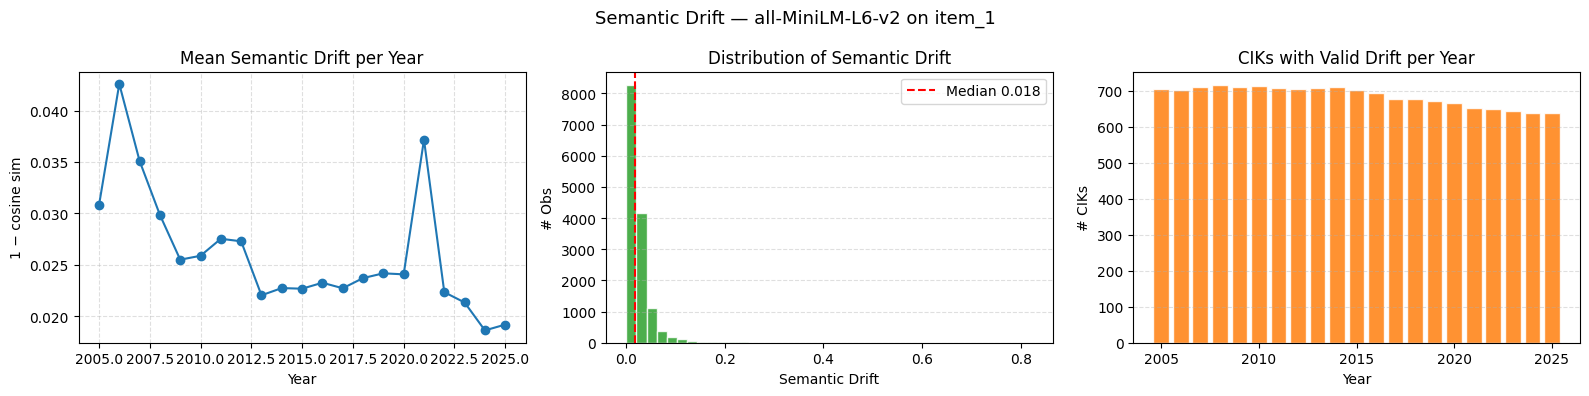

Done.


In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel A: Mean drift per year
annual = valid.groupby('year')['semantic_drift'].mean()
axes[0].plot(annual.index, annual.values, marker='o', color='#1f77b4', linewidth=1.5)
axes[0].set_title('Mean Semantic Drift per Year')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('1 − cosine sim')
axes[0].grid(linestyle='--', alpha=0.4)

# Panel B: Pooled distribution
axes[1].hist(valid['semantic_drift'], bins=40, color='#2ca02c', edgecolor='white', alpha=0.85)
axes[1].axvline(valid['semantic_drift'].median(), color='red', linestyle='--',
                label=f'Median {valid["semantic_drift"].median():.3f}')
axes[1].set_title('Distribution of Semantic Drift')
axes[1].set_xlabel('Semantic Drift'); axes[1].set_ylabel('# Obs')
axes[1].legend(); axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# Panel C: Coverage
cik_counts = valid.groupby('year')['cik'].nunique()
axes[2].bar(cik_counts.index, cik_counts.values, color='#ff7f0e', alpha=0.85, edgecolor='white')
axes[2].set_title('CIKs with Valid Drift per Year')
axes[2].set_xlabel('Year'); axes[2].set_ylabel('# CIKs')
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle(f'Semantic Drift — all-MiniLM-L6-v2 on {CONFIG["section"]}', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_folder'], 'semantic_drift_minilm_summary.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('Done.')